# Network Breakdown Side-by-Side

This notebook compares Yeo-7 network breakdowns for selected PCA and ICA components side by side.

It is set up for:
- PC11 vs IC12
- PC09 vs IC16

It saves:
- pairwise comparison plots
- a grid of all selected components
- CSV summaries

In [10]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn import datasets, image
from scipy import ndimage

In [11]:
# =========================
# USER SETTINGS / PATHS
# =========================

# --- PCA and ICA component files ---
PCA_IMG = "/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/group_pca_K20_components.nii.gz"
ICA_IMG = "/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/group_ica_K20_components.nii.gz"

# --- Output folder ---
OUTDIR = "/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/ComponentNetworkBreakdown"

# --- Component pairs to compare ---
# Use 1-based numbering here
COMPONENT_PAIRS = [
    ("PCA", 11, "ICA", 12),
    ("PCA", 9,  "ICA", 16),
]

# --- Thresholding settings ---
USE_THRESHOLD = True
TOP_PCT = 0.20   # top 20% absolute weights inside valid mask

# --- Plot settings ---
SAVE_PDF = True
FIG_DPI = 300

In [12]:
YEO7_LABELS = {
    1: "Visual",
    2: "Somatomotor",
    3: "Dorsal Attention",
    4: "Ventral Attention",
    5: "Limbic",
    6: "Frontoparietal",
    7: "Default",
}

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def component_label(kind, idx1):
    if kind.upper() == "PCA":
        return f"PC{idx1:02d}"
    elif kind.upper() == "ICA":
        return f"IC{idx1:02d}"
    else:
        return f"{kind}{idx1:02d}"

In [13]:
def make_eroded_mni_mask(ref_img):
    mni_mask = datasets.load_mni152_brain_mask()
    mni_rs = image.resample_to_img(
        mni_mask,
        ref_img,
        interpolation="nearest",
        force_resample=True
    )
    mask_data = np.squeeze(mni_rs.get_fdata()) > 0

    # Erode by 1 voxel to reduce edge artifacts
    eroded = ndimage.binary_erosion(mask_data, iterations=1)
    return mni_rs, eroded

def load_yeo7_resampled(ref_img):
    yeo = datasets.fetch_atlas_yeo_2011()
    yeo_img = nib.load(yeo.thick_7)

    yeo_rs = image.resample_to_img(
        yeo_img,
        ref_img,
        interpolation="nearest",
        force_resample=True
    )
    yeo_data = np.squeeze(yeo_rs.get_fdata()).astype(int)
    return yeo_rs, yeo_data

In [14]:
def load_component_array(img_path, idx1):
    img = nib.load(img_path)
    data = img.get_fdata()
    data = np.asarray(data)

    print(f"\nLoaded: {img_path}")
    print("Raw image shape:", data.shape)

    idx0 = idx1 - 1

    if data.ndim == 3:
        if idx1 != 1:
            raise ValueError(
                f"This file is 3D, so only one component exists. "
                f"You asked for component {idx1}."
            )
        comp = data

    elif data.ndim == 4:
        if idx0 < 0 or idx0 >= data.shape[3]:
            raise IndexError(
                f"Requested component {idx1}, but file has {data.shape[3]} components."
            )
        comp = data[..., idx0]

    else:
        raise ValueError(f"Unexpected image shape: {data.shape}")

    comp = np.squeeze(comp)

    if comp.ndim != 3:
        raise ValueError(f"Component is not 3D after squeeze: {comp.shape}")

    print("Selected component shape:", comp.shape)
    return comp, img

In [15]:
def threshold_top_fraction_abs(comp_data, valid_mask, top_pct=0.20):
    vals = np.abs(comp_data[valid_mask])

    if vals.size == 0:
        raise ValueError("No valid voxels available for thresholding.")

    cutoff = np.quantile(vals, 1.0 - top_pct)
    use_mask = valid_mask & (np.abs(comp_data) >= cutoff)
    return use_mask

def compute_network_breakdown(comp_data, yeo_data, mask_bool, top_pct=0.20, use_threshold=True):
    comp_data = np.squeeze(comp_data)
    yeo_data = np.squeeze(yeo_data)
    mask_bool = np.squeeze(mask_bool).astype(bool)

    print("comp_data shape:", comp_data.shape)
    print("yeo_data shape:", yeo_data.shape)
    print("mask_bool shape:", mask_bool.shape)

    if comp_data.ndim != 3:
        raise ValueError(f"comp_data must be 3D after squeeze, got {comp_data.shape}")
    if yeo_data.ndim != 3:
        raise ValueError(f"yeo_data must be 3D after squeeze, got {yeo_data.shape}")
    if mask_bool.ndim != 3:
        raise ValueError(f"mask_bool must be 3D after squeeze, got {mask_bool.shape}")

    if comp_data.shape != yeo_data.shape or comp_data.shape != mask_bool.shape:
        raise ValueError(
            f"Shape mismatch: comp={comp_data.shape}, yeo={yeo_data.shape}, mask={mask_bool.shape}"
        )

    valid = mask_bool & np.isfinite(comp_data) & (yeo_data >= 1) & (yeo_data <= 7)

    if not np.any(valid):
        raise ValueError("No valid voxels survived mask + atlas filtering.")

    if use_threshold:
        use_mask = threshold_top_fraction_abs(comp_data, valid, top_pct=top_pct)
    else:
        use_mask = valid

    if not np.any(use_mask):
        raise ValueError("No voxels survived thresholding.")

    absw = np.abs(comp_data)
    total = absw[use_mask].sum()

    rows = []
    for net_id, net_name in YEO7_LABELS.items():
        m = use_mask & (yeo_data == net_id)
        w = absw[m].sum()
        pct = 100.0 * w / total if total > 0 else 0.0

        rows.append({
            "network_id": net_id,
            "network": net_name,
            "weight_sum": float(w),
            "percent": float(pct),
            "n_voxels": int(m.sum())
        })

    df = pd.DataFrame(rows).sort_values("percent", ascending=False).reset_index(drop=True)
    return df

In [16]:
def plot_single_breakdown(ax, df, title):
    ax.bar(df["network"], df["percent"])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Percent of absolute weight")
    ax.set_ylim(0, max(5, df["percent"].max() * 1.15))
    ax.tick_params(axis="x", rotation=45)

def plot_pairwise_breakdown(df_left, title_left, df_right, title_right, out_png, out_pdf=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    plot_single_breakdown(axes[0], df_left, title_left)
    plot_single_breakdown(axes[1], df_right, title_right)

    fig.suptitle("Yeo-7 Network Breakdown", fontsize=14, fontweight="bold")
    fig.savefig(out_png, dpi=FIG_DPI, bbox_inches="tight")
    if out_pdf is not None:
        fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def plot_all_components_grid(results_dict, out_png, out_pdf=None):
    n = len(results_dict)
    fig, axes = plt.subplots(n, 1, figsize=(9, 4 * n), constrained_layout=True)

    if n == 1:
        axes = [axes]

    for ax, (label, df) in zip(axes, results_dict.items()):
        plot_single_breakdown(ax, df, label)

    fig.suptitle("Selected Component Network Breakdowns", fontsize=14, fontweight="bold")
    fig.savefig(out_png, dpi=FIG_DPI, bbox_inches="tight")
    if out_pdf is not None:
        fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Check paths

Run this cell first. If either file returns `False`, update the path above.

In [17]:
print("PCA exists:", os.path.exists(PCA_IMG))
print("ICA exists:", os.path.exists(ICA_IMG))
print("Output dir:", OUTDIR)

PCA exists: True
ICA exists: True
Output dir: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/ComponentNetworkBreakdown


In [18]:
ensure_dir(OUTDIR)

# Use PCA image as the reference space
pca_ref_img = nib.load(PCA_IMG)

mni_rs, eroded_mask = make_eroded_mni_mask(pca_ref_img)
yeo_rs, yeo_data = load_yeo7_resampled(pca_ref_img)

print("Reference shape:", np.squeeze(pca_ref_img.get_fdata()).shape)
print("Eroded mask shape:", eroded_mask.shape)
print("Yeo atlas shape:", yeo_data.shape)

Reference shape: (91, 109, 91, 20)
Eroded mask shape: (91, 109, 91)
Yeo atlas shape: (91, 109, 91)



Loaded: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/group_pca_K20_components.nii.gz
Raw image shape: (91, 109, 91, 20)
Selected component shape: (91, 109, 91)
comp_data shape: (91, 109, 91)
yeo_data shape: (91, 109, 91)
mask_bool shape: (91, 109, 91)

Loaded: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/group_ica_K20_components.nii.gz
Raw image shape: (91, 109, 91, 20)
Selected component shape: (91, 109, 91)
comp_data shape: (91, 109, 91)
yeo_data shape: (91, 109, 91)
mask_bool shape: (91, 109, 91)


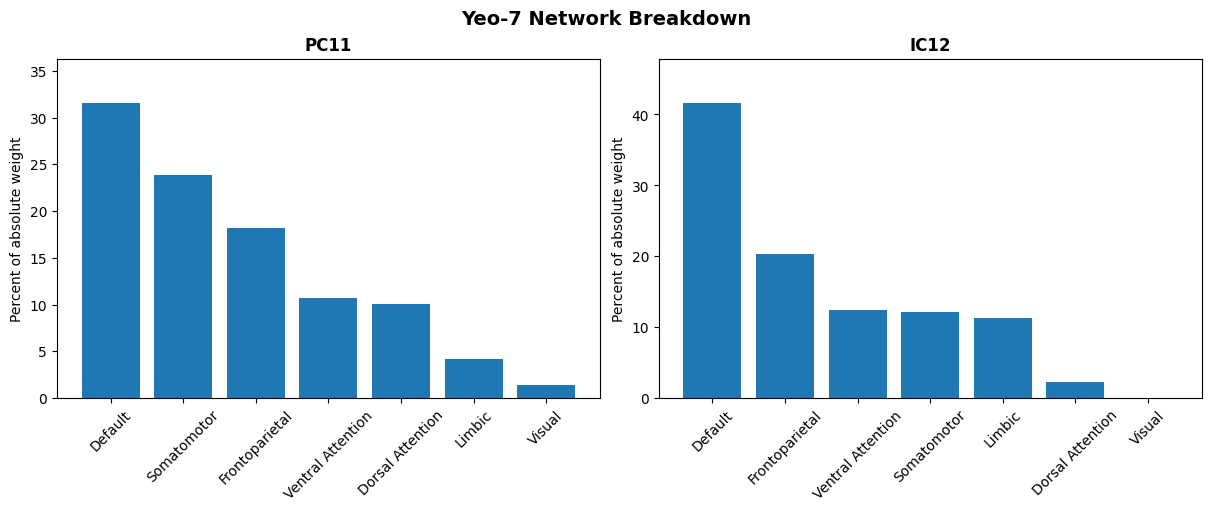


Loaded: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/group_pca_K20_components.nii.gz
Raw image shape: (91, 109, 91, 20)
Selected component shape: (91, 109, 91)
comp_data shape: (91, 109, 91)
yeo_data shape: (91, 109, 91)
mask_bool shape: (91, 109, 91)

Loaded: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/group_ica_K20_components.nii.gz
Raw image shape: (91, 109, 91, 20)
Selected component shape: (91, 109, 91)
comp_data shape: (91, 109, 91)
yeo_data shape: (91, 109, 91)
mask_bool shape: (91, 109, 91)


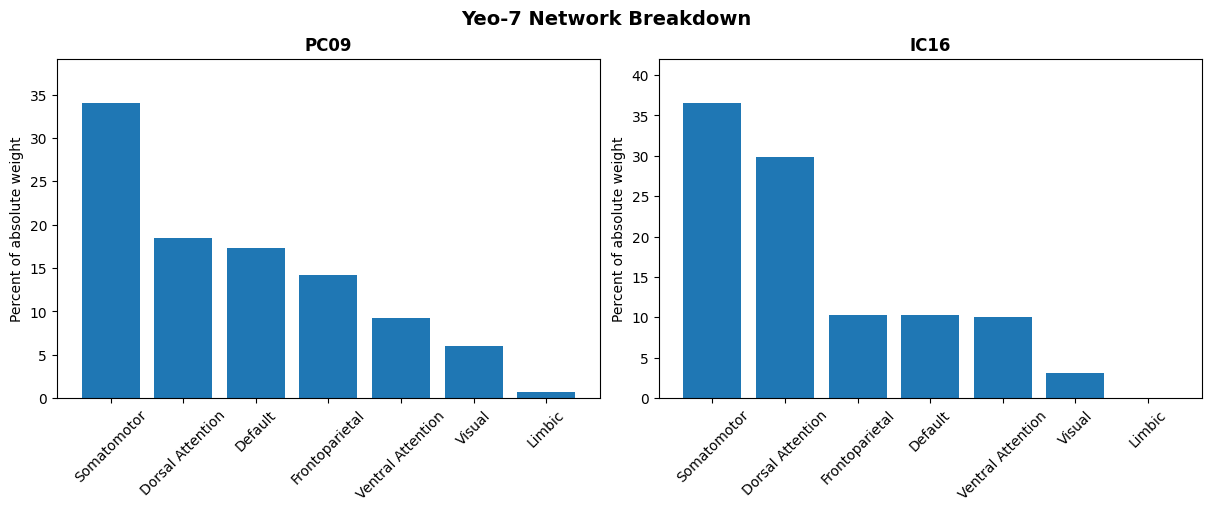

In [19]:
all_rows = []
all_results = {}

for left_kind, left_idx, right_kind, right_idx in COMPONENT_PAIRS:
    pair_items = [(left_kind, left_idx), (right_kind, right_idx)]
    pair_dfs = []

    for kind, idx1 in pair_items:
        img_path = PCA_IMG if kind.upper() == "PCA" else ICA_IMG

        comp, comp_img = load_component_array(img_path, idx1)

        # Convert selected 3D component back to image, then resample to PCA reference
        comp_3d_img = nib.Nifti1Image(comp, comp_img.affine, comp_img.header)
        comp_rs = image.resample_to_img(
            comp_3d_img,
            pca_ref_img,
            interpolation="continuous",
            force_resample=True
        )

        comp_rs_data = np.squeeze(comp_rs.get_fdata())

        df = compute_network_breakdown(
            comp_data=comp_rs_data,
            yeo_data=yeo_data,
            mask_bool=eroded_mask,
            top_pct=TOP_PCT,
            use_threshold=USE_THRESHOLD
        )

        label = component_label(kind, idx1)
        df.insert(0, "component", label)

        all_rows.append(df.copy())
        all_results[label] = df.copy()
        pair_dfs.append((label, df.copy()))

    label1, df1 = pair_dfs[0]
    label2, df2 = pair_dfs[1]

    out_png = os.path.join(OUTDIR, f"{label1}_vs_{label2}_network_breakdown.png")
    out_pdf = os.path.join(OUTDIR, f"{label1}_vs_{label2}_network_breakdown.pdf") if SAVE_PDF else None

    plot_pairwise_breakdown(df1, label1, df2, label2, out_png, out_pdf)

In [20]:
combined_df = pd.concat(all_rows, ignore_index=True)
combined_csv = os.path.join(OUTDIR, "component_network_breakdown_selected_pairs.csv")
combined_df.to_csv(combined_csv, index=False)

top3_rows = []
for comp_label, df in all_results.items():
    top3 = df.sort_values("percent", ascending=False).head(3).copy()
    top3.insert(0, "component", comp_label)
    top3_rows.append(top3)

top3_df = pd.concat(top3_rows, ignore_index=True)
top3_csv = os.path.join(OUTDIR, "component_network_breakdown_top3_summary.csv")
top3_df.to_csv(top3_csv, index=False)

print("Saved:", combined_csv)
print("Saved:", top3_csv)

ValueError: cannot insert component, already exists

In [ ]:
grid_png = os.path.join(OUTDIR, "network_breakdown_individual_components.png")
grid_pdf = os.path.join(OUTDIR, "network_breakdown_individual_components.pdf") if SAVE_PDF else None

plot_all_components_grid(all_results, grid_png, grid_pdf)

print("Saved:", grid_png)
if grid_pdf:
    print("Saved:", grid_pdf)

In [ ]:
for label, df in all_results.items():
    print("\n" + "="*60)
    print(label)
    display(df)

## Notes

- This notebook extracts a single component safely from a 4D PCA/ICA file.
- It squeezes singleton dimensions to avoid the `(91,109,91)` vs `(91,109,91,1)` broadcast error.
- If a path error happens, use **Copy as Pathname** from Finder and paste the exact file path into the settings cell.